In [ ]:
import pandas as pd

# データの読み込み
plant1_gen_df = pd.read_csv("../data/raw/Plant_1_Generation_Data.csv")
plant1_weather_df = pd.read_csv("../data/raw/Plant_1_Weather_Sensor_Data.csv")

# 何行・何列あるか確認
print("発電データ:", plant1_gen_df.shape)
print("気象データ:", plant1_weather_df.shape)

# 最初の5行を見てみる
plant1_gen_df.head()


発電データ: (68778, 7)
気象データ: (3182, 6)


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [49]:
plant1_weather_df.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [50]:
# ユニークなインバーターのID（SOURCE_KEY）の数を確認
print("インバーターの台数:", plant1_gen_df["SOURCE_KEY"].nunique())

インバーターの台数: 22


In [51]:
# プラント1の発電データに欠損値がない確認
plant1_gen_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 68778 entries, 0 to 68777
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE_TIME    68778 non-null  str    
 1   PLANT_ID     68778 non-null  int64  
 2   SOURCE_KEY   68778 non-null  str    
 3   DC_POWER     68778 non-null  float64
 4   AC_POWER     68778 non-null  float64
 5   DAILY_YIELD  68778 non-null  float64
 6   TOTAL_YIELD  68778 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 5.7 MB


In [ ]:
# プラント1の天候データに欠損値がない確認
plant1_weather_df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   DATE_TIME            3182 non-null   str    
 1   PLANT_ID             3182 non-null   int64  
 2   SOURCE_KEY           3182 non-null   str    
 3   AMBIENT_TEMPERATURE  3182 non-null   float64
 4   MODULE_TEMPERATURE   3182 non-null   float64
 5   IRRADIATION          3182 non-null   float64
dtypes: float64(3), int64(1), str(2)
memory usage: 254.9 KB


In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 日時型への変換
plant1_gen_df['DATE_TIME'] = pd.to_datetime(plant1_gen_df['DATE_TIME'])

# データの期間（最初と最後の日付）を念のため確認
print("データの開始日:", plant1_gen_df['DATE_TIME'].min())
print("データの終了日:", plant1_gen_df['DATE_TIME'].max())

データの開始日: 2020-05-15 00:00:00
データの終了日: 2020-06-17 23:45:00


/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/1803283266.py:6: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  plant1_gen_df['DATE_TIME'] = pd.to_datetime(plant1_gen_df['DATE_TIME'])


/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/578857405.py:22: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/578857405.py:22: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/578857405.py:22: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hayatotateshita/Documents/develop/solar-power-forecasting-system/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hayatotateshita/Documents/develop/solar-power-forecasting-system/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: Use

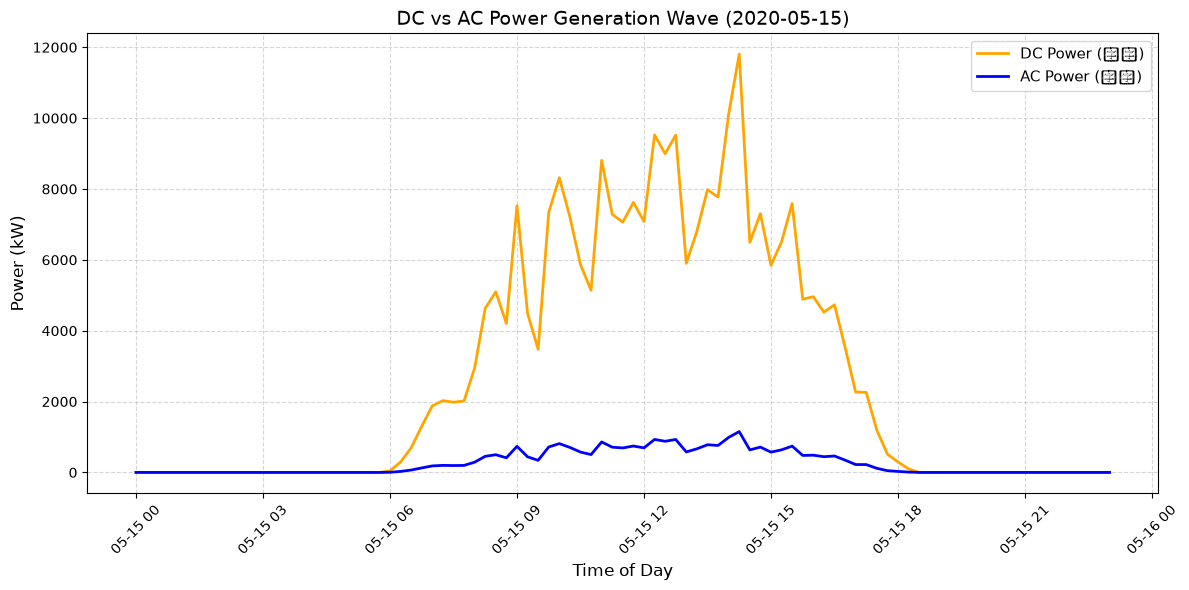

In [54]:
# 1. 抽出したい日付を指定（お好きな日付に変えて実験できます）
target_date = '2020-05-15'

# 2. 指定した日付のデータだけをフィルタリング
day_df = plant1_gen_df[plant1_gen_df['DATE_TIME'].dt.date == pd.to_datetime(target_date).date()]

# 3. インバーターごとに動きが若干違うため、今回は「全体の平均的な動き」をプロット
# （特定の1台に絞りたい場合は、ここでSOURCE_KEYを指定してフィルタリングしてもOKです）
hourly_avg = day_df.groupby('DATE_TIME')[['DC_POWER', 'AC_POWER']].mean().reset_index()

# 4. グラフの描画
plt.figure(figsize=(12, 6))
plt.plot(hourly_avg['DATE_TIME'], hourly_avg['DC_POWER'], label='DC Power (直流)', color='orange', lw=2)
plt.plot(hourly_avg['DATE_TIME'], hourly_avg['AC_POWER'], label='AC Power (交流)', color='blue', lw=2)

plt.title(f"DC vs AC Power Generation Wave ({target_date})", fontsize=14)
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Power (kW)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

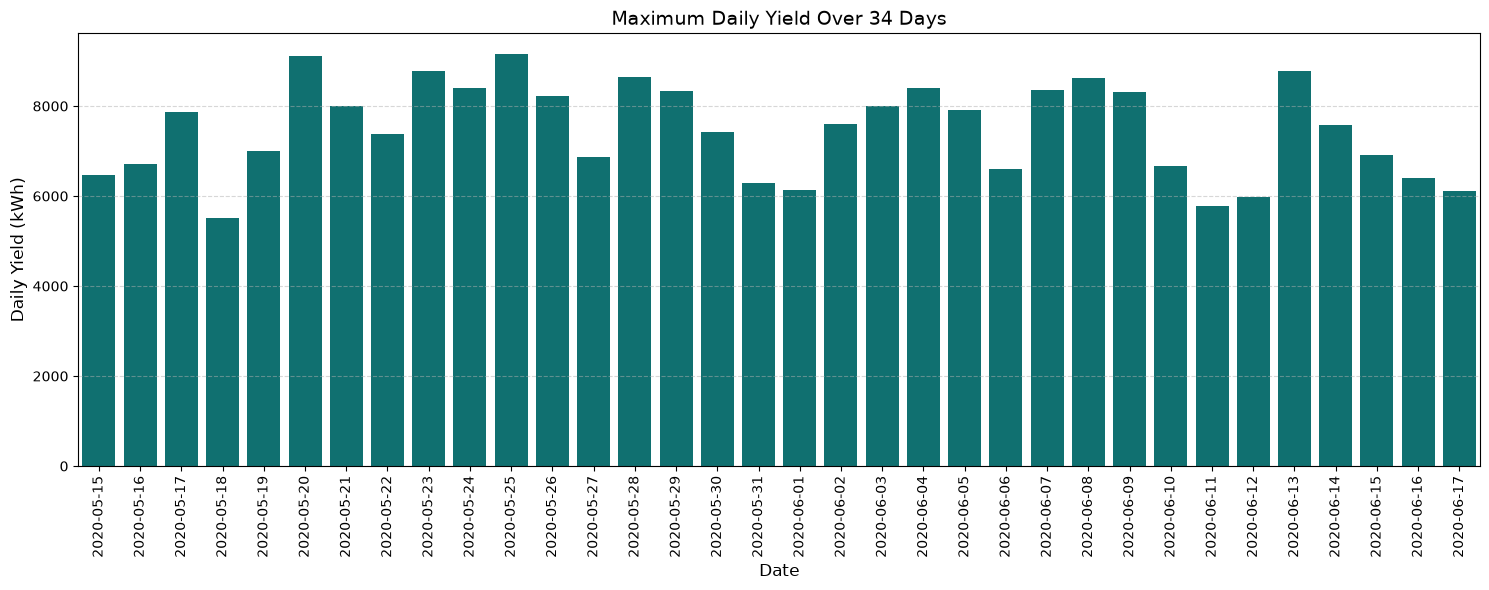

In [55]:
# 1. 「日付」だけの列を一時的に作る
plant1_gen_df['DATE'] = plant1_gen_df['DATE_TIME'].dt.date

# 2. 日付ごとに、DAILY_YIELDの最大値（その日の最終累積）を計算
daily_yield_max = plant1_gen_df.groupby('DATE')['DAILY_YIELD'].max().reset_index()

# 3. グラフの描画
plt.figure(figsize=(15, 6))
sns.barplot(data=daily_yield_max, x='DATE', y='DAILY_YIELD', color='teal')

plt.title("Maximum Daily Yield Over 34 Days", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Yield (kWh)", fontsize=12)
plt.xticks(rotation=90) # 日付が見やすいように90度回転
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Total Yield (kWh)')

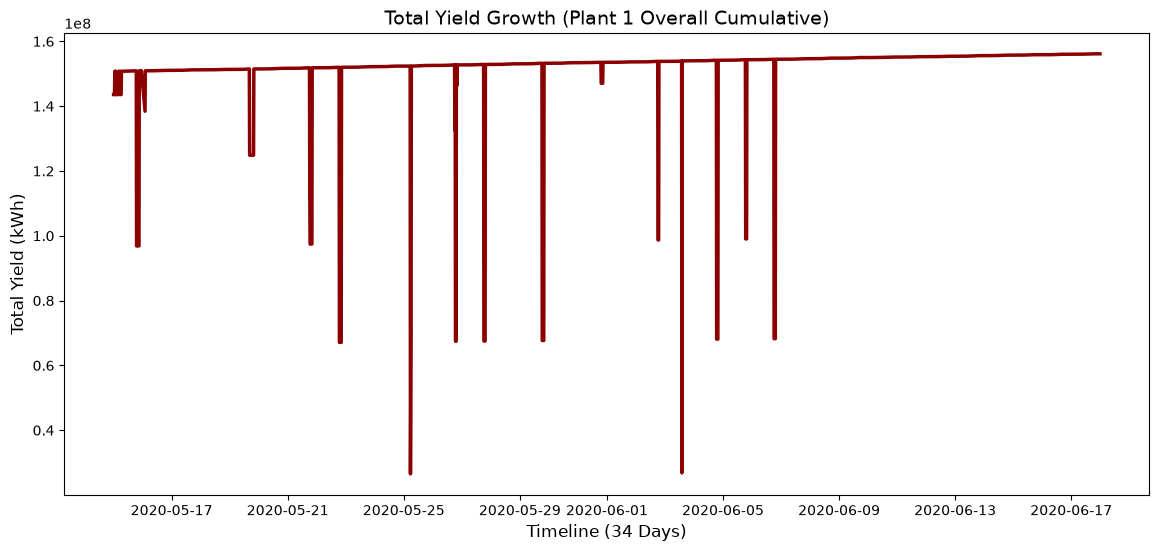

In [59]:
# 1. 時間ごとに、全インバーターのTOTAL_YIELDを合計して発電所全体の累積にする
total_yield_trend = plant1_gen_df.groupby('DATE_TIME')['TOTAL_YIELD'].sum().reset_index()

# 2. グラフの描画
plt.figure(figsize=(14, 6))
plt.plot(total_yield_trend['DATE_TIME'], total_yield_trend['TOTAL_YIELD'], color='darkred', lw=2.5)

plt.title("Total Yield Growth (Plant 1 Overall Cumulative)", fontsize=14)
plt.xlabel("Timeline (34 Days)", fontsize=12)
plt.ylabel("Total Yield (kWh)", fontsize=12)

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# 日時型への変換（まだやっていない場合）
plant1_weather_df['DATE_TIME'] = pd.to_datetime(plant1_weather_df['DATE_TIME'])

/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/3951003731.py:13: UserWarning: Glyph 27671 (\N{CJK UNIFIED IDEOGRAPH-6C17}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/3951003731.py:13: UserWarning: Glyph 28201 (\N{CJK UNIFIED IDEOGRAPH-6E29}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/3951003731.py:13: UserWarning: Glyph 12497 (\N{KATAKANA LETTER PA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/3951003731.py:13: UserWarning: Glyph 12493 (\N{KATAKANA LETTER NE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/3951003731.py:13: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000

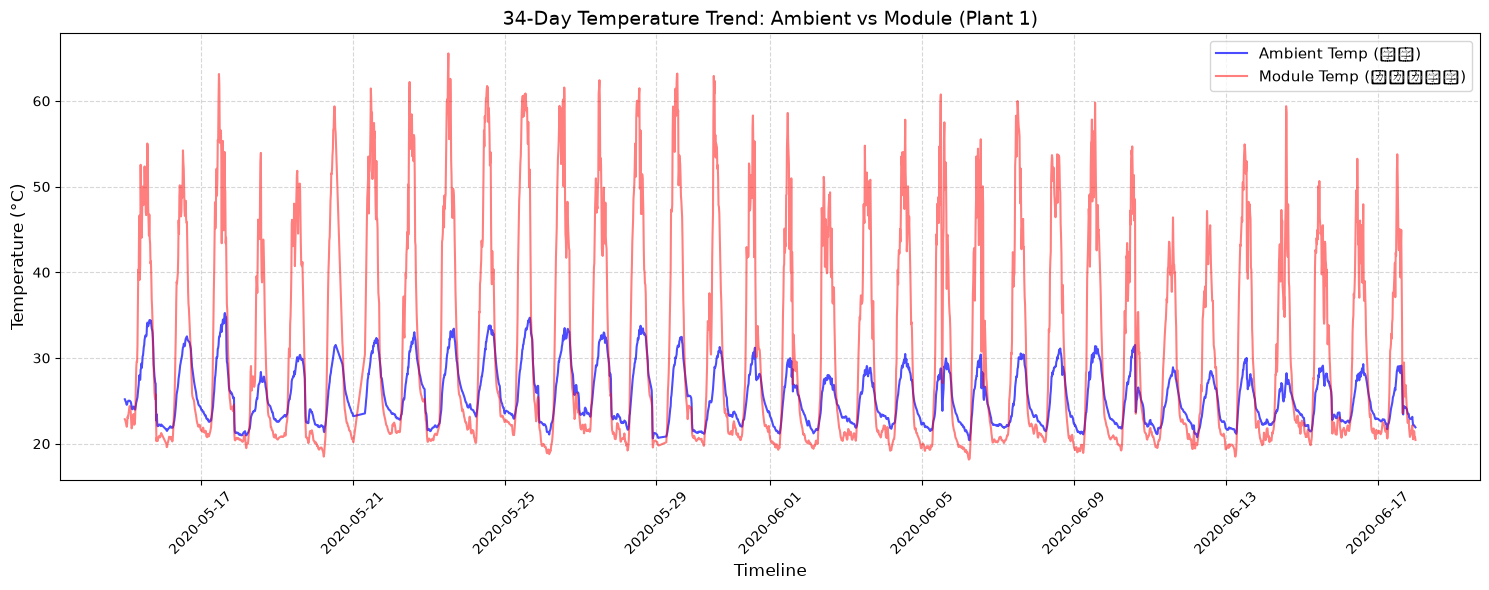

In [61]:
plt.figure(figsize=(15, 6))

# 気温とパネル温度を重ねて描画
plt.plot(plant1_weather_df['DATE_TIME'], plant1_weather_df['AMBIENT_TEMPERATURE'], label='Ambient Temp (気温)', color='blue', alpha=0.7)
plt.plot(plant1_weather_df['DATE_TIME'], plant1_weather_df['MODULE_TEMPERATURE'], label='Module Temp (パネル温度)', color='red', alpha=0.5)

plt.title("34-Day Temperature Trend: Ambient vs Module (Plant 1)", fontsize=14)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Temperature (°C)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/2233577230.py:17: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/2233577230.py:17: UserWarning: Glyph 23556 (\N{CJK UNIFIED IDEOGRAPH-5C04}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/vd/3z40pz013hz0wjckp9xwk7hh0000gn/T/ipykernel_17624/2233577230.py:17: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/hayatotateshita/Documents/develop/solar-power-forecasting-system/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hayatotateshita/Documents/develop/solar-power-forecasting-system/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: 

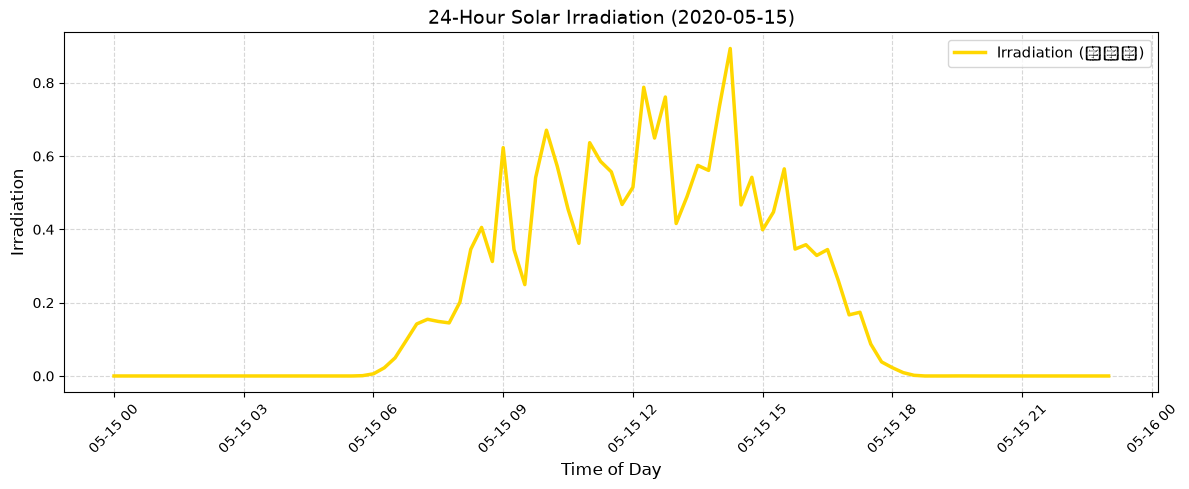

In [62]:
# 1. 抽出したい日付を指定（発電データと同じ日にするのがプロのコツ！）
target_date_weather = '2020-05-15'

# 2. 指定した日付のデータだけをフィルタリング
day_weather_df = plant1_weather_df[plant1_weather_df['DATE_TIME'].dt.date == pd.to_datetime(target_date_weather).date()]

# 3. グラフの描画
plt.figure(figsize=(12, 5))
plt.plot(day_weather_df['DATE_TIME'], day_weather_df['IRRADIATION'], color='gold', lw=2.5, label='Irradiation (日射量)')

plt.title(f"24-Hour Solar Irradiation ({target_date_weather})", fontsize=14)
plt.xlabel("Time of Day", fontsize=12)
plt.ylabel("Irradiation", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()